##  Project : Smart City Traffic Forecasting

This project focuses on analyzing and forecasting hourly traffic patterns across four junctions in a city.
# The goal is to help improve traffic management and support infrastructure planning using data-driven insights.

# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Loading Train & Test Data

In [ ]:
train = pd.read_csv("train_aWnotuB.csv")
test = pd.read_csv("datasets_8494_11879_test_BdBKkAj.csv")

train["DateTime"] = pd.to_datetime(train["DateTime"])
test["DateTime"] = pd.to_datetime(test["DateTime"])

In [ ]:
train["is_train"] = 1
test["is_train"] = 0

test["Vehicles"] = np.nan  # because test has no target

data = pd.concat([train, test]).sort_values("DateTime").copy()

# Hourly Traffic Pattern

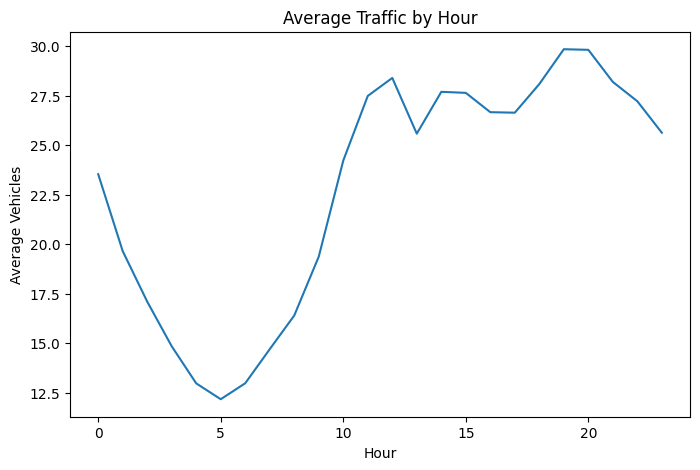

In [ ]:
data["Hour"] = data["DateTime"].dt.hour

hourly_avg = data.groupby("Hour")["Vehicles"].mean()

plt.figure(figsize=(8,5))
hourly_avg.plot()
plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Vehicles")
plt.show()

# Junction Comparison

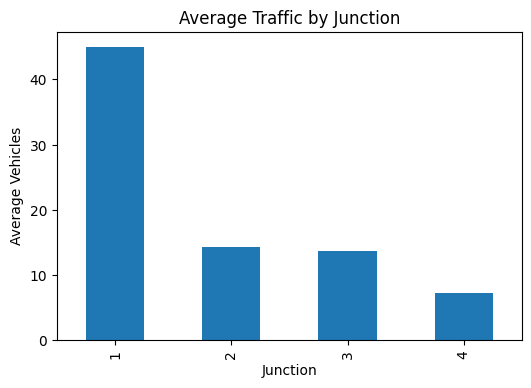

In [ ]:
junction_avg = data.groupby("Junction")["Vehicles"].mean()

plt.figure(figsize=(6,4))
junction_avg.plot(kind="bar")
plt.title("Average Traffic by Junction")
plt.ylabel("Average Vehicles")
plt.show()

## Data Preprocessing and Feature Engineering

To prepare the data for modeling, the following steps were performed:

1. Converted DateTime column into datetime format.
2. Extracted time-based features:
   - Hour
   - Day
   - Month
   - Weekday

3. Created lag features to capture temporal dependency:
   - Lag_1 (previous hour traffic)
   - Lag_2 (two hours before)
   - Lag_24 (same hour previous day)

Traffic data is highly autocorrelated, meaning current traffic depends on past traffic.
Lag features significantly improve prediction performance.

# 4. Created a Time_Index feature to capture long-term trend.

# Time Features

In [ ]:
data["Hour"] = data["DateTime"].dt.hour
data["Day"] = data["DateTime"].dt.day
data["Month"] = data["DateTime"].dt.month
data["Weekday"] = data["DateTime"].dt.weekday

# Creating Lag Features

In [ ]:
data["Lag_1"] = data.groupby("Junction")["Vehicles"].shift(1)
data["Lag_2"] = data.groupby("Junction")["Vehicles"].shift(2)
data["Lag_24"] = data.groupby("Junction")["Vehicles"].shift(24)

In [ ]:
train_data = data[data["is_train"] == 1].dropna().copy()
test_data = data[data["is_train"] == 0].copy()

In [ ]:
test_data = test_data.sort_values("DateTime")

test_data = test_data.groupby("Junction").apply(lambda x: x.ffill())
test_data = test_data.reset_index(drop=True)

/tmp/ipython-input-160/3982212112.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_data = test_data.groupby("Junction").apply(lambda x: x.ffill())


In [ ]:
print(test_data.isna().sum())

DateTime        0
Junction        0
Vehicles    11808
ID              0
is_train        0
Hour            0
Day             0
Month           0
Weekday         0
Lag_1           0
Lag_2           0
Lag_24          0
dtype: int64


In [ ]:
train_data = pd.get_dummies(train_data, columns=["Junction"], drop_first=True)
test_data = pd.get_dummies(test_data, columns=["Junction"], drop_first=True)

train_data, test_data = train_data.align(test_data, join="left", axis=1, fill_value=0)

In [ ]:
split_index = int(len(train_data) * 0.8)

train_split = train_data.iloc[:split_index]
val_split = train_data.iloc[split_index:]

X_train_val = train_split.drop(["Vehicles", "DateTime", "ID", "is_train"], axis=1)
y_train_val = train_split["Vehicles"]

X_val = val_split.drop(["Vehicles", "DateTime", "ID", "is_train"], axis=1)
y_val = val_split["Vehicles"]

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train_val, y_train_val)
y_val_pred = rf_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 4.962822148973118


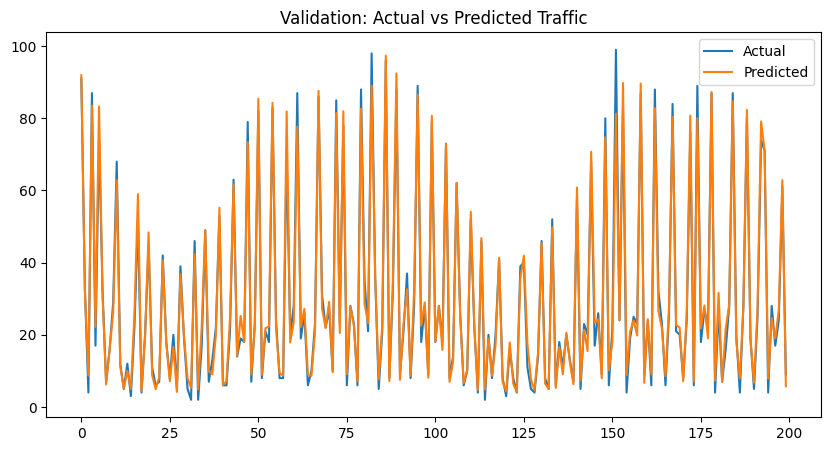

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_val_pred[:200], label="Predicted")
plt.legend()
plt.title("Validation: Actual vs Predicted Traffic")
plt.show()

In [ ]:
X_train_full = train_data.drop(["Vehicles", "DateTime", "ID", "is_train"], axis=1)
y_train_full = train_data["Vehicles"]

rf_model.fit(X_train_full, y_train_full)

RandomForestRegressor(max_depth=20, min_samples_leaf=5, n_estimators=300,
                      random_state=42)

In [ ]:
X_test = test_data.drop(["Vehicles", "DateTime", "ID", "is_train"], axis=1)

test_data["Vehicles"] = rf_model.predict(X_test)

In [ ]:
submission = test_data[["ID", "Vehicles"]]
submission.to_csv("submission.csv", index=False)

print(submission.head())
print(submission.shape)

            ID   Vehicles
0  20170701001  80.795895
1  20170701011  67.847402
2  20170701021  67.270042
3  20170701031  67.300998
4  20170701041  66.449513
(11808, 2)


## Final Model Training and Test Prediction

After validation, the model was retrained on the full training dataset to maximize learning.

Predictions were then generated for the official test dataset.

The final submission file contains:
- ID
# - Predicted Vehicles

## Policy Recommendations

Based on the analysis:

1. Adaptive traffic signal timing should be implemented during peak hours.
2. Junction 3 may require infrastructure upgrades or better traffic routing.
3. Real-time monitoring systems should be integrated for continuous prediction.


## Conclusion

This project presents a complete end-to-end traffic forecasting solution.

Using time-series feature engineering and a tuned Random Forest model,
traffic patterns across four junctions were successfully analyzed and predicted.

The system can assist government authorities in traffic planning, congestion control,and infrastructure development for a smarter city.

In [ ]:
import joblib
joblib.dump(rf_model, "traffic_model.pkl")

['traffic_model.pkl']

In [ ]:
print(X_train_full.columns)
print(len(X_train_full.columns))

Index(['Hour', 'Day', 'Month', 'Weekday', 'Lag_1', 'Lag_2', 'Lag_24',
       'Junction_2', 'Junction_3', 'Junction_4'],
      dtype='object')
10
